In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [ ]:
df = pd.read_csv("/kaggle/input/datasets/agneaybnair/test-data/clv_data.csv",index_col=0)

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
df.dtypes

In [ ]:
sns.heatmap(df.isnull())
plt.show()

In [ ]:
#Mean imputation
df["age"] = df["age"].fillna(df["age"].mean()) 

In [ ]:
df["days_on_platform"] = df["days_on_platform"].fillna(df["days_on_platform"].mean())

In [ ]:
#Distribution of Age
df["age"].hist(bins=10)
plt.title("Age distribution")
plt.show()

In [ ]:
#Income Distribution
df["income"].hist(bins=10)
plt.title("Income Distribution")
plt.show()

In [ ]:
print(df["income"].std(),df["income"].var())

In [ ]:
# Box Plot
sns.boxplot(x=df["income"])
plt.show()

In [ ]:
# IQR Method
Q1 = df["income"].quantile(0.25)
Q3 = df["income"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print(lower,upper)

In [ ]:
#finding outliers
outliers = df[(df["income"] < lower) |
(df["income"] > upper)]
outliers.shape

In [ ]:
df_clean = df[
    (df["income"] >= lower) &
    (df["income"] <= upper)
]

In [ ]:
#winsorization
df["income"] = np.where(
    df["income"] > upper,
    upper,
    df["income"]
)

In [ ]:
df.info()

In [ ]:
## Categorical Analysis
sns.histplot(df["income"], kde=True)

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
for col in ["gender", "city"]:
    print(df[col].value_counts())
    print("-"*30)

gender
Male      2553
Female    2447
Name: count, dtype: int64
------------------------------
city
Tokyo            1018
Miami            1016
New York City    1003
San Francisco     987
London            976
Name: count, dtype: int64
------------------------------


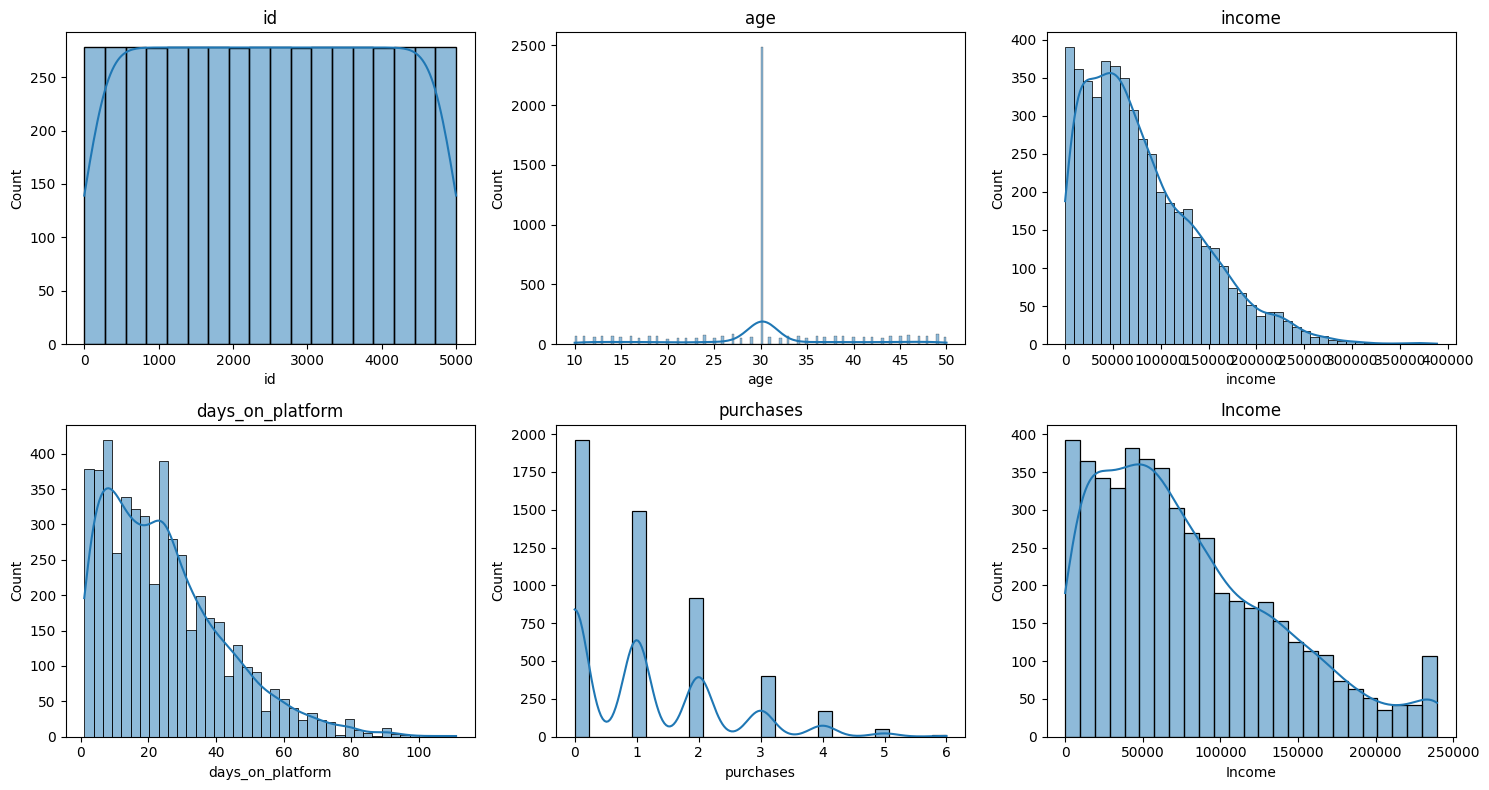

In [23]:
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

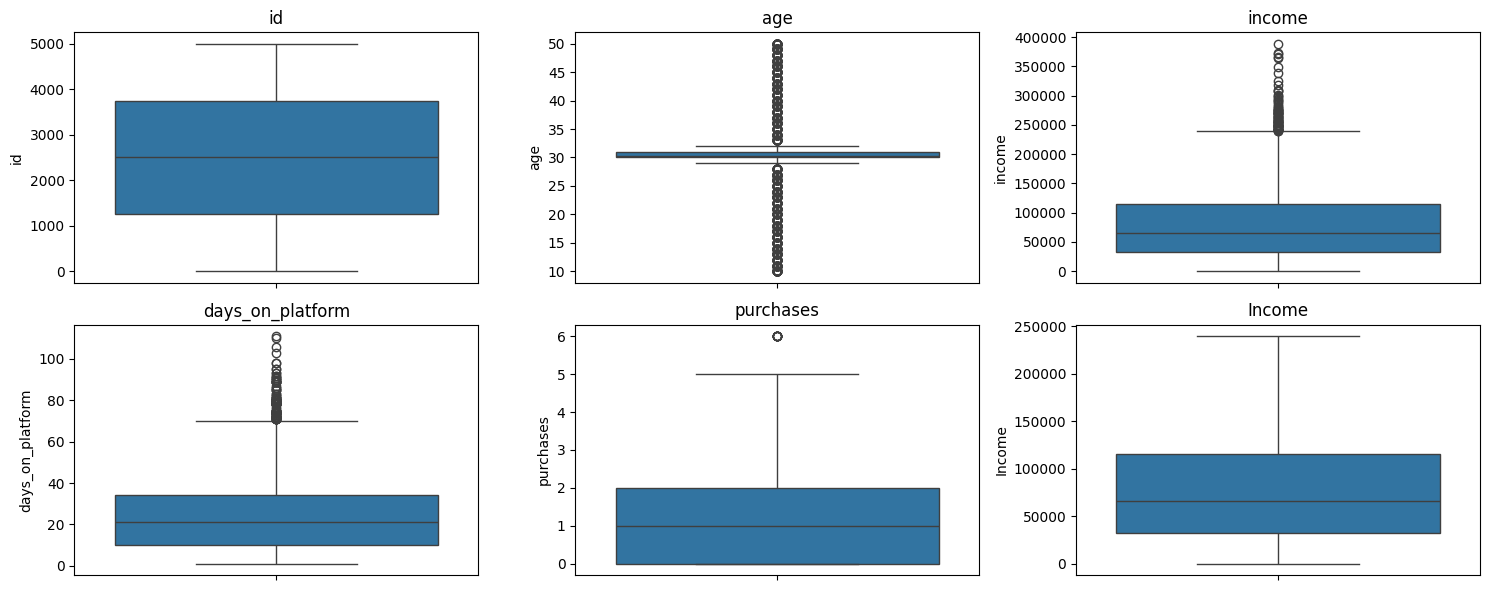

In [24]:
plt.figure(figsize=(15,6))

for i, col in enumerate(num_cols,1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

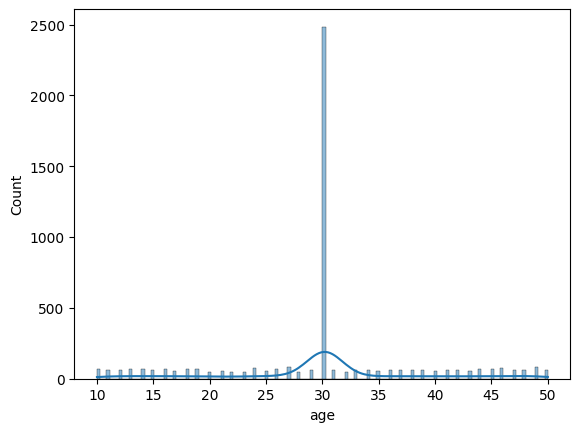

In [25]:
sns.histplot(df["age"], kde=True)
plt.show()

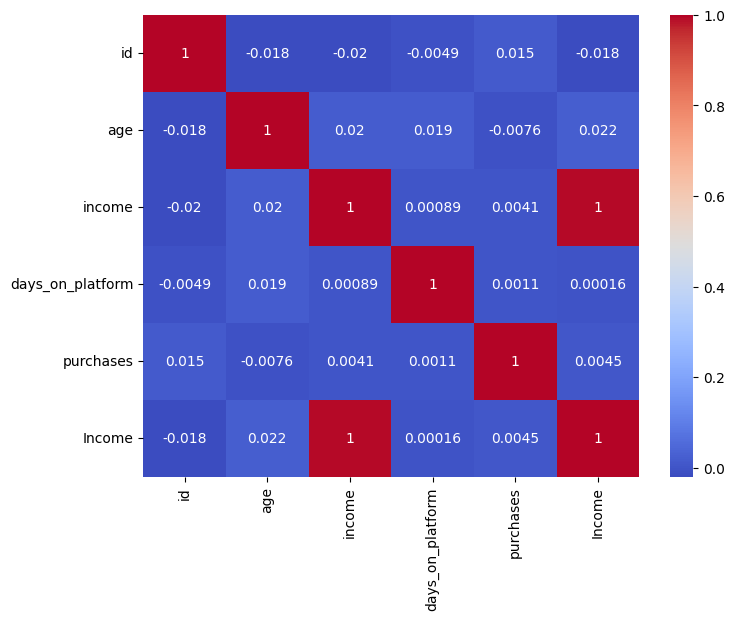

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [27]:
print(df.info())

print(df.isnull().sum())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                5000 non-null   int64  
 1   age               5000 non-null   float64
 2   gender            5000 non-null   object 
 3   income            5000 non-null   int64  
 4   days_on_platform  5000 non-null   float64
 5   city              5000 non-null   object 
 6   purchases         5000 non-null   int64  
 7   Income            5000 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 351.6+ KB
None
id                  0
age                 0
gender              0
income              0
days_on_platform    0
city                0
purchases           0
Income              0
dtype: int64
                id          age         income  days_on_platform    purchases  \
count  5000.000000  5000.000000    5000.000000       5000.000000  5000.000000   
mean   24

# Inference

1. The dataset contains 5,000 customer records with demographic and behavioral information such as age, gender, income, city, days on the platform, and purchase history.
2. The age column has a large number of missing values (2,446, about 49%), making it the most significant data quality issue. Appropriate imputation (e.g., median) is required before further analysis.
3. The days_on_platform column contains only 141 missing values (about 2.8%), which can be safely handled through imputation without significantly affecting the dataset.
4. No duplicate records were found, indicating that each customer record is unique.
5. The Unnamed: 0 column is an unnecessary index column and was removed because it does not contribute any meaningful information.
6. Boxplots revealed the presence of outliers in numerical features, particularly income. These outliers were identified using the IQR method and can either be removed or capped (winsorization) depending on the analysis objective.
7. Histograms show the distribution of numerical variables, helping identify skewness and understand the spread of customer attributes.
8. Count plots of categorical variables such as gender and city provide insights into the distribution of customers across different categories.
9. The correlation heatmap helps identify relationships among numerical variables. Strong correlations may indicate useful predictors, while weak correlations suggest that variables capture different aspects of customer behavior.
10. After handling missing values and outliers, the dataset becomes cleaner, more consistent, and better suited for statistical analysis, visualization, and machine learning tasks.


## Conclusion

The dataset was successfully cleaned by handling missing values, removing unnecessary columns, checking for duplicates, identifying and treating outliers, and validating the final data quality. These preprocessing steps improve the reliability of subsequent analyses and ensure that any models or business insights derived from the dataset are based on accurate and consistent data.